<a href="https://colab.research.google.com/github/Suchrahmadhani/DataScience-Practicum/blob/main/Pertemuan4_Suci_Rahmadhani_240401070508.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: Statistika Dasar & Analisis Data

## Identitas Mahasiswa

| Keterangan | Informasi |
|------------|-----------|
| **Nama** | Suci Rahmadhani |
| **NIM** | 240401070508 |
| **Kelas** | IF404 |
| **Program Studi** | PJJ Informatika |
| **Mata Kuliah** | Data Science |

# Tujuan Praktikum

Pada praktikum ini saya mempelajari konsep statistika deskriptif dan analisis data menggunakan dataset Iris. Praktikum meliputi proses eksplorasi dataset, perhitungan statistik deskriptif, analisis distribusi data, visualisasi menggunakan histogram, boxplot, violin plot, scatter plot, serta analisis korelasi menggunakan matriks korelasi Pearson dan heatmap.

# Ringkasan Materi

Statistika deskriptif merupakan tahap awal dalam analisis data yang bertujuan untuk memahami karakteristik suatu dataset. Beberapa ukuran statistik yang umum digunakan antara lain mean, median, varians, standar deviasi, skewness, dan kurtosis.

Visualisasi data seperti histogram, boxplot, violin plot, scatter plot, dan heatmap membantu memahami distribusi data, mendeteksi pola, serta mengetahui hubungan antar variabel. Dataset Iris digunakan sebagai contoh karena merupakan salah satu dataset klasik dalam pembelajaran Data Science.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Eksplorasi Awal Dataset

In [2]:
df = sns.load_dataset("iris")

print("Shape Dataset:", df.shape)
print()

print("Tipe Data")
print(df.dtypes)

print()

print("Lima Data Pertama")
display(df.head())

print()

print("Statistik Deskriptif")
display(df.describe().round(3))

Shape Dataset: (150, 5)

Tipe Data
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Lima Data Pertama


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Statistik Deskriptif


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


### Interpretasi

Dataset Iris terdiri dari 150 baris dan 5 kolom yang berisi informasi mengenai ukuran sepal, ukuran petal, dan spesies bunga Iris. Sebelum melakukan analisis lebih lanjut, dilakukan eksplorasi awal untuk mengetahui ukuran dataset, tipe data setiap kolom, serta ringkasan statistik deskriptif. Dataset ini tidak memiliki missing values sehingga dapat langsung digunakan dalam proses analisis statistik.

# Statistik Deskriptif Lengkap

In [3]:
for col_name in df.select_dtypes(include="number").columns:

    col = df[col_name]

    print("=" * 45)
    print(f"Kolom : {col_name}")
    print("=" * 45)

    print(f"Mean       : {col.mean():.3f}")
    print(f"Median     : {col.median():.3f}")
    print(f"Varians    : {col.var():.3f}")
    print(f"Std Dev    : {col.std():.3f}")
    print(f"Skewness   : {col.skew():.3f}")
    print(f"Kurtosis   : {col.kurt():.3f}")

    print()

Kolom : sepal_length
Mean       : 5.843
Median     : 5.800
Varians    : 0.686
Std Dev    : 0.828
Skewness   : 0.315
Kurtosis   : -0.552

Kolom : sepal_width
Mean       : 3.057
Median     : 3.000
Varians    : 0.190
Std Dev    : 0.436
Skewness   : 0.319
Kurtosis   : 0.228

Kolom : petal_length
Mean       : 3.758
Median     : 4.350
Varians    : 3.116
Std Dev    : 1.765
Skewness   : -0.275
Kurtosis   : -1.402

Kolom : petal_width
Mean       : 1.199
Median     : 1.300
Varians    : 0.581
Std Dev    : 0.762
Skewness   : -0.103
Kurtosis   : -1.341



### Interpretasi

Hasil statistik deskriptif menunjukkan karakteristik setiap variabel numerik pada dataset Iris.

- **Mean** menunjukkan nilai rata-rata setiap variabel.
- **Median** menunjukkan nilai tengah data sehingga tidak terlalu dipengaruhi oleh nilai ekstrem.
- **Varians** dan **standar deviasi** menggambarkan tingkat penyebaran data terhadap rata-ratanya.
- **Skewness** digunakan untuk mengetahui bentuk distribusi data, apakah simetris, miring ke kanan (positif), atau miring ke kiri (negatif).
- **Kurtosis** menunjukkan bentuk puncak distribusi dibandingkan distribusi normal. Nilai mendekati nol menunjukkan distribusi yang relatif menyerupai distribusi normal.

Melalui statistik deskriptif ini dapat diketahui bahwa setiap variabel memiliki karakteristik penyebaran yang berbeda sehingga analisis visual perlu dilakukan pada tahap berikutnya.

In [4]:
print("Kuartil dan Persentil")

display(
    df.describe(percentiles=[0.25, 0.5, 0.75]).round(3)
)

Kuartil dan Persentil


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


### Interpretasi

Selain ukuran pemusatan dan penyebaran, tabel di atas juga menampilkan nilai kuartil (Q1, Q2/Median, dan Q3). Kuartil membagi data menjadi empat bagian sehingga dapat membantu memahami sebaran data serta mendeteksi kemungkinan adanya outlier pada setiap variabel.

# Analisis Distribusi Data (Histogram + KDE)

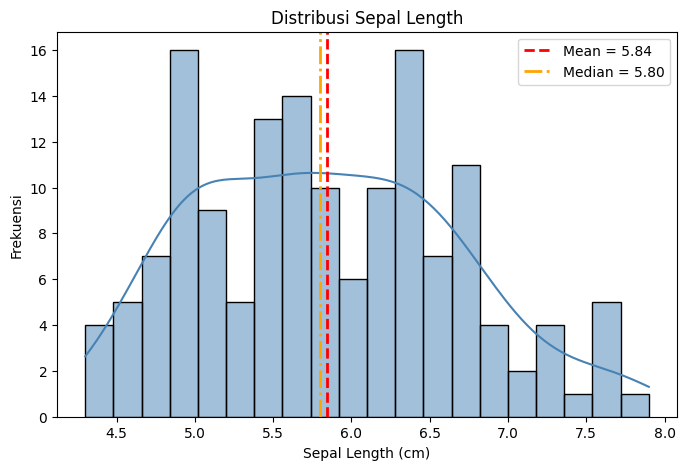

In [5]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df,
    x="sepal_length",
    kde=True,
    bins=20,
    color="steelblue",
    ax=ax
)

# Garis Mean
ax.axvline(
    df["sepal_length"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis Median
ax.axvline(
    df["sepal_length"].median(),
    color="orange",
    linestyle="-.",
    linewidth=2,
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title("Distribusi Sepal Length")
ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Frekuensi")

ax.legend()

plt.show()

### Interpretasi

Histogram menunjukkan distribusi nilai **sepal_length** pada dataset Iris, sedangkan kurva **Kernel Density Estimation (KDE)** memberikan gambaran bentuk distribusi data secara lebih halus.

Garis merah menunjukkan nilai **mean**, sedangkan garis oranye menunjukkan nilai **median**. Kedua nilai tersebut berada pada posisi yang relatif berdekatan sehingga distribusi data cenderung cukup seimbang dan tidak menunjukkan kemencengan (skewness) yang ekstrem.

Berdasarkan bentuk histogram dan kurva KDE, distribusi **sepal_length** terlihat mendekati distribusi normal meskipun terdapat beberapa puncak yang dipengaruhi oleh adanya tiga spesies bunga Iris yang berbeda.

# Boxplot dan Violin Plot berdasarkan Species

/tmp/ipykernel_10839/4016791492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10839/4016791492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


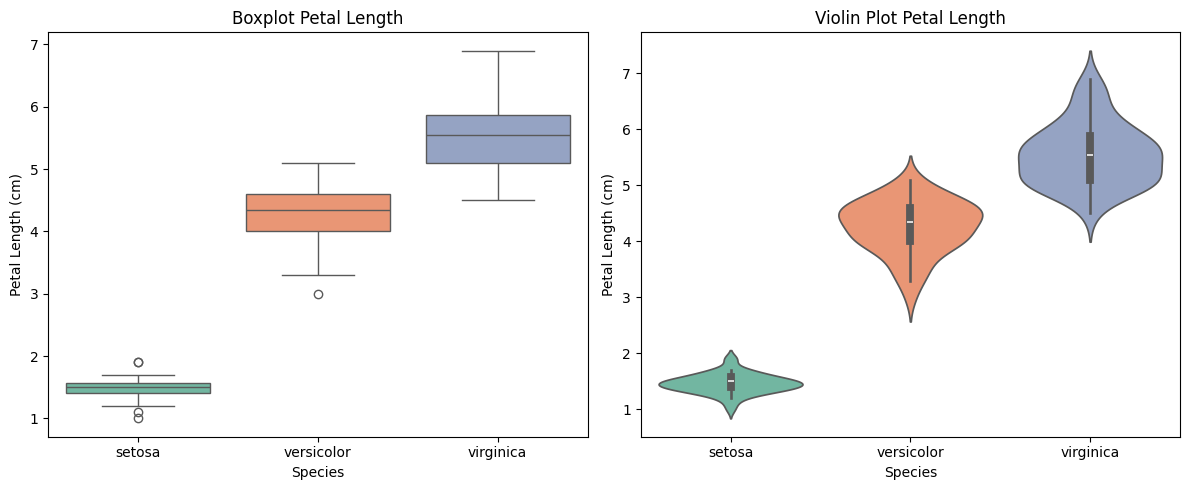

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(
    data=df,
    x="species",
    y="petal_length",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Boxplot Petal Length")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Petal Length (cm)")

# Violin Plot
sns.violinplot(
    data=df,
    x="species",
    y="petal_length",
    palette="Set2",
    inner="box",
    ax=axes[1]
)

axes[1].set_title("Violin Plot Petal Length")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Petal Length (cm)")

plt.tight_layout()
plt.show()

### Interpretasi

Visualisasi boxplot dan violin plot menunjukkan perbedaan distribusi panjang petal pada masing-masing spesies bunga Iris.

Berdasarkan hasil visualisasi:

- **Iris virginica** memiliki nilai **petal_length** paling besar.
- **Iris setosa** memiliki nilai **petal_length** paling kecil.
- **Iris versicolor** berada di antara keduanya.
- Sebaran data paling besar terlihat pada **Iris virginica**, sedangkan **Iris setosa** memiliki sebaran yang paling sempit.

Boxplot memudahkan dalam melihat median, kuartil, dan kemungkinan outlier, sedangkan violin plot memberikan informasi tambahan mengenai bentuk distribusi data pada setiap spesies.

# Matriks Korelasi Pearson

In [7]:
corr = df.drop("species", axis=1).corr(method="pearson")

print("Matriks Korelasi Pearson")

display(corr.round(3))

Matriks Korelasi Pearson


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


In [8]:
mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f"Korelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}")

Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


### Interpretasi

Matriks korelasi Pearson menunjukkan tingkat hubungan linear antar variabel numerik pada dataset Iris.

Hasil analisis menunjukkan bahwa pasangan variabel dengan korelasi tertinggi memiliki hubungan yang sangat kuat, sedangkan pasangan dengan korelasi terendah memiliki hubungan yang jauh lebih lemah.

Informasi ini penting karena dapat membantu memilih variabel yang saling berkaitan serta memahami karakteristik dataset sebelum dilakukan analisis lanjutan maupun pemodelan machine learning.

# Scatter Plot dan Heatmap Korelasi

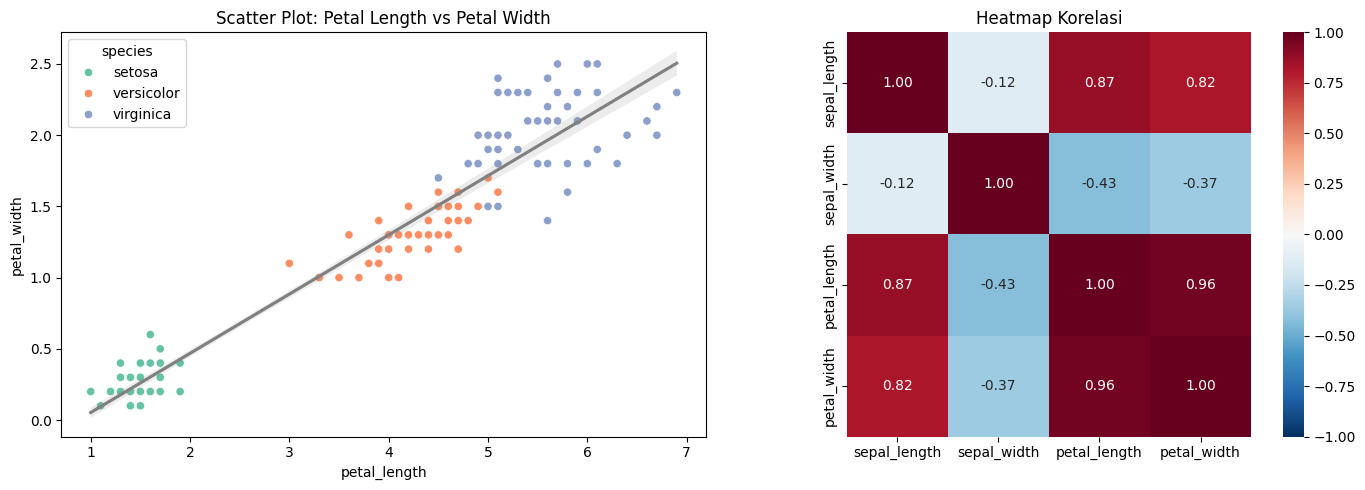

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi")

plt.tight_layout()
plt.show()

### Interpretasi Scatter Plot dan Heatmap

Scatter plot menunjukkan bahwa **petal_length** dan **petal_width** memiliki hubungan positif yang sangat kuat. Semakin panjang mahkota bunga (petal), maka lebarnya juga cenderung semakin besar. Selain itu, titik-titik dari setiap spesies terlihat membentuk kelompok yang cukup jelas sehingga kedua variabel tersebut dapat digunakan untuk membedakan spesies Iris.

Heatmap korelasi memperlihatkan bahwa pasangan **petal_length** dan **petal_width** memiliki nilai korelasi paling tinggi dibandingkan pasangan variabel lainnya. Sementara itu, hubungan antara **sepal_width** dengan beberapa variabel lain cenderung lebih lemah. Visualisasi ini mempermudah proses identifikasi hubungan antarvariabel sebelum dilakukan analisis lebih lanjut.

# Kesimpulan

Pada praktikum ini saya mempelajari penerapan statistik deskriptif menggunakan dataset Iris. Saya melakukan eksplorasi data, menghitung ukuran pemusatan dan penyebaran data, menganalisis distribusi menggunakan histogram dan KDE, membandingkan distribusi antarspesies melalui boxplot dan violin plot, serta menganalisis hubungan antarvariabel menggunakan korelasi Pearson, scatter plot, dan heatmap.

Berdasarkan hasil analisis, variabel **petal_length** dan **petal_width** memiliki hubungan positif yang sangat kuat sehingga menjadi variabel yang paling efektif untuk membedakan spesies bunga Iris. Praktikum ini membantu saya memahami pentingnya analisis statistik deskriptif dan visualisasi data sebagai langkah awal sebelum membangun model analisis maupun machine learning.